# MITGCM Intermediate Parameters Processing for regional surface heat flux Analysis

**Purpose**: Code for computing intermediate derived variables from the model diagnostics for the heat forcing analysis. 

**Luke Colosi | lcolosi@ucsd.edu**

Force matplotlib plots to display directly within the output cell of the notebook

In [1]:
%matplotlib inline

Import python libraries

In [2]:
import sys
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt 
from netCDF4 import Dataset, num2date
from datetime import datetime
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import os
import cmocean
from scipy.interpolate import interp1d
import gsw
from pyproj import Proj, Transformer
from geopy.distance import geodesic
from scipy.interpolate import RegularGridInterpolator

# Set path to access python functions
ROOT = '/Users/lukecolosi/Desktop/projects/graduate_research/Gille_lab/'
sys.path.append(ROOT + 'AirSeaCoupling/tools/')

#--- Other Functions ---# 
import cartopy_figs as cart

Set data analysis parameters

In [3]:
# Set processing parameters
option_grad          = 1

# Set path to project directory
PATH = ROOT + 'AirSeaCoupling/data/mitgcm/SWOT_MARA_RUN4_LY/spatial/regional/'

Load mitgcm data netcdf files 

In [4]:
#------------------------------------------# 
# Heat and Salt Flux Processing
#------------------------------------------# 

# Obtain filename paths
filename_tflux = PATH + "TFLUX_CCS4_DLY_map_2D.nc"
filename_sflux = PATH + "SFLUX_CCS4_DLY_map_2D.nc"
filename_Qsw = PATH + "oceQsw_CCS4_daily_map_surface.nc"

# Generate the nc data structure
nc_tflux = Dataset(filename_tflux, 'r')
nc_sflux = Dataset(filename_sflux, 'r')
nc_Qsw = Dataset(filename_Qsw, 'r')

# Extract data variables
lon = nc_tflux.variables['XC'][:]
lat = nc_tflux.variables['YC'][:]
time =  num2date(nc_tflux.variables['time'][:], nc_tflux.variables['time'].units)

Q_net_raw  = nc_tflux.variables['TFLUX'][:]
Q_sw_raw   = nc_Qsw.variables['oceQsw'][:]
S_flux_raw = nc_sflux.variables['SFLUX'][:]

# Mask data at fill values (zero for the MITgcm output)
Q_net_m = np.ma.masked_where(Q_net_raw == 0, Q_net_raw)
Q_sw_m = np.ma.masked_where(Q_sw_raw == 0, Q_sw_raw)
S_flux_m = np.ma.masked_where(S_flux_raw == 0, S_flux_raw)

# Convert cftime.DatetimeGregorian to Python datetime objects
time_dt = np.array([datetime(d.year, d.month, d.day, d.hour, d.minute, d.second) for d in time])

Grab data from Jan 1, 2016 to Dec 31, 2017 to be consistent with time scale analysis

In [5]:
# Set time index for 2016 through 2017
idx_time = (time_dt >= datetime(2016, 1, 1)) & (time_dt < datetime(2018, 1, 1))

# Subset data to time index
Q_net_m  = Q_net_m[idx_time, :, :]
Q_sw_m   = Q_sw_m[idx_time, :, :]
S_flux_m = S_flux_m[idx_time, :, :]
time_dt  = time_dt[idx_time]

### Interpolate onto CalCOFI Transect 

Set CalCOFI station locations

In [6]:
# Manually read in station locations
calcofi_lat = np.array([34.46667, 34.45, 34.31667, 34.15, 33.81667, 33.48333, 33.15, 32.81667])
calcofi_lon = np.array([-120.48906, -120.5239, -120.80245, -121.15, -121.84304, -122.53335, -123.22099, -123.90599])

Compute cumulative diastance along line 80.0 

In [7]:
# Initialize array 
dist = np.zeros(len(calcofi_lon))

# Loop through stations 
for i in range(1,len(calcofi_lon)): 

    # Define i and i + 1 points along transect
    pt1 = (calcofi_lat[i-1], calcofi_lon[i-1])
    pt2 = (calcofi_lat[i],   calcofi_lon[i])

    # Compute distance in kilometers along transect
    dist[i] = dist[i-1] + geodesic(pt1, pt2).km

Create a denser distance axis (near the resolution of the model grid)

In [8]:
# Set spacing (units: kilometer)
dr = 2 

# Generate a denser array 
dist_dense = np.arange(0, dist[-1], dr)

# Interpolate lat and longitude along this denser line
calcofi_lat_dense = np.interp(dist_dense, dist, calcofi_lat)
calcofi_lon_dense = np.interp(dist_dense, dist, calcofi_lon)

# Remove points along the CalCOFI transect that are outside of the domain of model (-120.5 to -123.0, 33.0 to 35.0)
idx_lat = (calcofi_lat_dense > np.min(lat)) & (calcofi_lat_dense < np.max(lat))
idx_lon = (calcofi_lon_dense < np.max(lon-360)) & (calcofi_lon_dense > np.min(lon-360))
idx = idx_lat & idx_lon

dist_dense_c = dist_dense[idx] 
calcofi_lat_dense_c = calcofi_lat_dense[idx]
calcofi_lon_dense_c = calcofi_lon_dense[idx]

# Convert the calcofi longitude to span from 0 to 360 
calcofi_lon_dense_c = (calcofi_lon_dense_c + 360) % 360

Interpolate model onto transect 

In [9]:
# --------------------------------------------------
# Create interpolation coordinates
# --------------------------------------------------
# Interpolator expects coordinates in the order:
# (lat, lon)

points_interp = np.column_stack((calcofi_lat_dense_c, calcofi_lon_dense_c))

# --------------------------------------------------
# Allocate output array
# --------------------------------------------------
n_time = len(time_dt)
n_dist = len(calcofi_lon_dense_c)

Q_net_trans = np.full((n_time, n_dist), np.nan)
Q_sw_trans = np.full((n_time, n_dist), np.nan)
S_flux_trans = np.full((n_time, n_dist), np.nan)

# --------------------------------------------------
# Interpolate each time slice
# --------------------------------------------------
for tt in range(n_time):

    # Set progress bar
    progress = (tt + 1) / (len(time_dt))
    sys.stdout.write(f"\rProgress: {progress:.1%}")
    sys.stdout.flush()

    # Create interpolator for this time slice
    interp_func_Q_net = RegularGridInterpolator(
        (lat, lon),
        Q_net_m[tt, :, :],
        method='linear',
        bounds_error=False,
        fill_value=np.nan
    )
    interp_func_Q_sw = RegularGridInterpolator(
        (lat, lon),
        Q_sw_m[tt, :, :],
        method='linear',
        bounds_error=False,
        fill_value=np.nan
    )
    interp_func_S_flux = RegularGridInterpolator(
        (lat, lon),
        S_flux_m[tt, :, :],
        method='linear',
        bounds_error=False,
        fill_value=np.nan
    )

    # Interpolate onto CalCOFI line 80
    Q_net_trans[tt, :]       = interp_func_Q_net(points_interp)
    Q_sw_trans[tt, :]       = interp_func_Q_sw(points_interp)
    S_flux_trans[tt, :]    = interp_func_S_flux(points_interp)

Progress: 100.0%

Remove the NaNs from the transect interpolation (NaNs arise because the regional domain for the wind stress data does not contain the entire CalCOFI line 80 transect)

In [10]:
# Find the indices of nonNaNs
idx = ~np.isnan(Q_net_trans[0,:])

# Remove NaNs 
dist_n           = dist_dense_c[idx]
lat_trans        = calcofi_lat_dense_c[idx]
lon_trans        = calcofi_lon_dense_c[idx]
Q_net_trans      = Q_net_trans[:,idx]
Q_sw_trans       = Q_sw_trans[:,idx]
S_flux_trans     = S_flux_trans[:,idx]

Set plotting parameters

In [11]:
# Set font and fontsize
os.environ["PATH"] = "/usr/local/texlive/2022/bin/universal-darwin:" + os.environ["PATH"]
fontsize = 15
plt.rcParams.update({
    "font.size": fontsize,         # Fontsize
    "text.usetex": True,           # Use LaTeX for all text
    "font.family": "serif",        # Optional: match LaTeX font
    "text.latex.preamble": r"\usepackage{amsmath}"  # Optional: load extra LaTeX packages
}) 

Plot an example of the transect

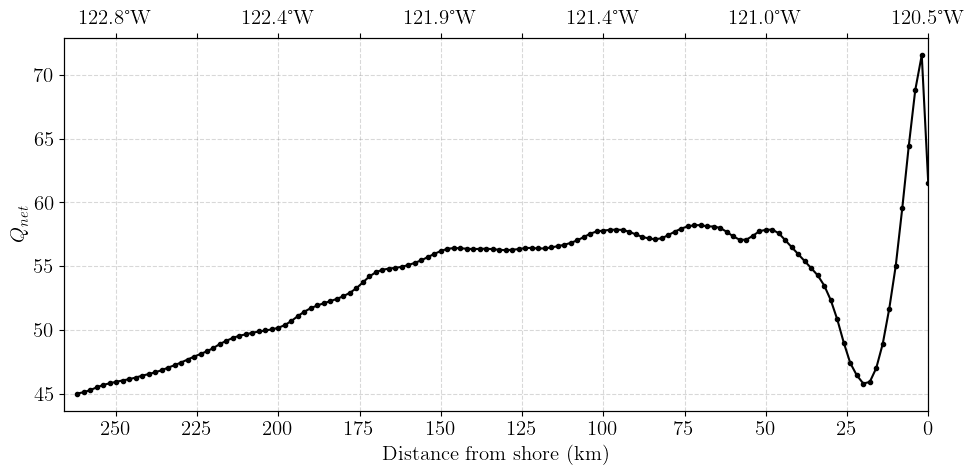

In [12]:
# Set plotting parameter
Q_net_trans_m = np.mean(Q_net_trans, axis=0) 

# Create figure
fig, ax = plt.subplots(figsize=(10,5))

#--- Subplot 1 ---# 

# Plot the wind stress curl along the transect
cf = ax.plot(dist_n[:-2],Q_net_trans_m[:-2], '.-k', lw = 1.5)

# Set axis attributes
ax.set_xlabel('Distance from shore (km)')
ax.set_ylabel(r'$Q_{net}$')
ax.set_xlim(0,dist_n[-1])
ax.set_xticks(np.arange(0,250+25,25))
ax.invert_xaxis()
ax.grid(linestyle='--',alpha=0.3,color='grey')

# --- Create top axis for longitude --- #
ax_top = ax.twiny()

# Make sure limits match
ax_top.set_xlim(ax.get_xlim())

# Choose where you want longitude ticks (same positions as distance ticks)
dist_ticks = ax.get_xticks()

# Interpolate longitude at those distance values
lon_180 = ((lon_trans + 180) % 360) - 180
lon_ticks = np.interp(dist_ticks, dist_n, lon_180)

# Create labels but only keep every other one
labels = [
    f"{abs(x):.1f}°W" if i % 2 == 0 else ""
    for i, x in enumerate(lon_ticks)
]

# Set ticks and labels
ax_top.set_xticks(dist_ticks)
ax_top.set_xticklabels(labels) 

sort_idx = np.argsort(lon_180)
lon_sorted = lon_180[sort_idx]
dist_sorted = dist_n[sort_idx]

# Display 
plt.tight_layout()
plt.show()

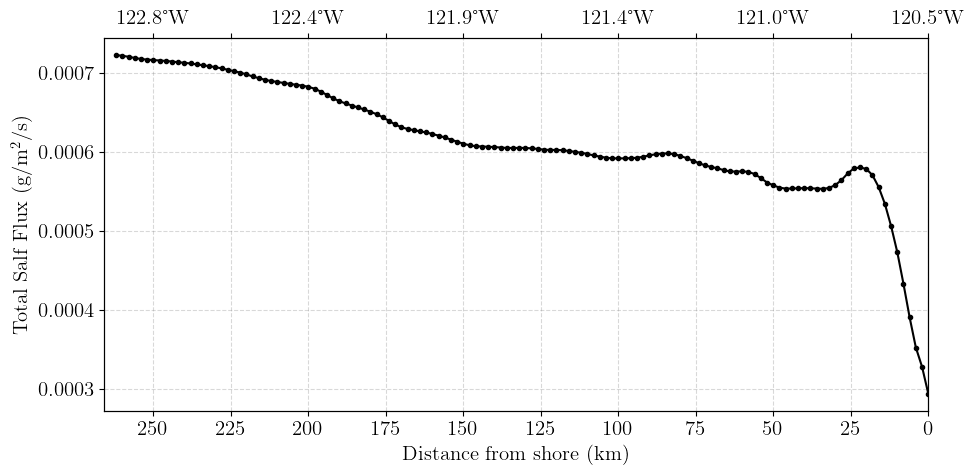

In [13]:
# Set plotting parameter
S_flux_trans_m = np.mean(S_flux_trans, axis=0) 

# Create figure
fig, ax = plt.subplots(figsize=(10,5))

#--- Subplot 1 ---# 

# Plot the wind stress curl along the transect
cf = ax.plot(dist_n[:-2],S_flux_trans_m[:-2], '.-k', lw = 1.5)

# Set axis attributes
ax.set_xlabel('Distance from shore (km)')
ax.set_ylabel(r'Total Salf Flux (g/m$^2$/s)')
ax.set_xlim(0,dist_n[-1])
ax.set_xticks(np.arange(0,250+25,25))
ax.invert_xaxis()
ax.grid(linestyle='--',alpha=0.3,color='grey')

# --- Create top axis for longitude --- #
ax_top = ax.twiny()

# Make sure limits match
ax_top.set_xlim(ax.get_xlim())

# Choose where you want longitude ticks (same positions as distance ticks)
dist_ticks = ax.get_xticks()

# Interpolate longitude at those distance values
lon_180 = ((lon_trans + 180) % 360) - 180
lon_ticks = np.interp(dist_ticks, dist_n, lon_180)

# Create labels but only keep every other one
labels = [
    f"{abs(x):.1f}°W" if i % 2 == 0 else ""
    for i, x in enumerate(lon_ticks)
]

# Set ticks and labels
ax_top.set_xticks(dist_ticks)
ax_top.set_xticklabels(labels) 

sort_idx = np.argsort(lon_180)
lon_sorted = lon_180[sort_idx]
dist_sorted = dist_n[sort_idx]

# Display 
plt.tight_layout()
plt.show()


Save intermediate data in a netCDF for future use

In [14]:
# Save variables in data arrays

#--- Transect Latitude and longitude ---# 

lat_trans = xr.DataArray(data=lat_trans,
                    dims=['dist'],
                    coords=dict(dist=dist_n),
                    attrs=dict(
                        description='The positions in latitude along the CalCOFI line 80 transect.',
                        units='degrees North'
                    )
)

lon_trans = xr.DataArray(data=lon_trans,
                    dims=['dist'],
                    coords=dict(dist=dist_n),
                    attrs=dict(
                        description='The positions in longitude along the CalCOFI line 80 transect.',
                        units='degrees East'
                    )
)

#--- Regional ---#
Q_net_reg = xr.DataArray(data=Q_net_m,
                    dims=['time','lat','lon'],
                    coords=dict(time=time_dt,lat=lat,lon=lon),
                    attrs=dict(
                        description='Total heat flux on (XC,YC) grid.',
                        units='W/m^2'
                    )
)

Q_sw_reg = xr.DataArray(data=Q_sw_m,
                    dims=['time','lat','lon'],
                    coords=dict(time=time_dt,lat=lat,lon=lon),
                    attrs=dict(
                        description='Shortwave heat flux on (XC,YC) grid.',
                        units='W/m^2'
                    )
)

S_flux_reg = xr.DataArray(data=Q_sw_m,
                    dims=['time','lat','lon'],
                    coords=dict(time=time_dt,lat=lat,lon=lon),
                    attrs=dict(
                        description='Total salt flux on (XC,YC) grid.',
                        units='g/m^2/s'
                    )
)

#--- Transect ---#
Q_net_trans = xr.DataArray(data=Q_net_trans,
                    dims=['time','dist'],
                    coords=dict(time=time_dt,dist=dist_n),
                    attrs=dict(
                        description='Total heat flux on (XC,YC) grid.',
                        units='W/m^2'
                    )
)

Q_sw_trans = xr.DataArray(data=Q_sw_trans,
                    dims=['time','dist'],
                    coords=dict(time=time_dt,dist=dist_n),
                    attrs=dict(
                        description='Shortwave heat flux on (XC,YC) grid.',
                        units='W/m^2'
                    )
)

S_flux_trans = xr.DataArray(data=S_flux_trans,
                    dims=['time','dist'],
                    coords=dict(time=time_dt,dist=dist_n),
                    attrs=dict(
                        description='Total salt flux on (XC,YC) grid.',
                        units='g/m^2/s'
                    )
)

# Create a data set from data arrays 
data = xr.Dataset({'lon_trans':lon_trans,'lat_trans':lat_trans,'Q_net_reg':Q_net_reg,'Q_sw_reg':Q_net_reg,'S_flux_reg':S_flux_reg,'Q_net_trans':Q_net_trans,'Q_sw_trans':Q_sw_trans,'S_flux_trans':S_flux_trans})
file_path = PATH + "/mitgcm_intermediate_data_heat_salt_flux_dly_map.nc"

# Check if file exists, then delete it
if os.path.exists(file_path):
    os.remove(file_path)

# Create netcdf file
data.to_netcdf(file_path,mode='w')